# Pnemonia Classifier Using Pytorch

In [1]:
import zipfile

with zipfile.ZipFile("/content/drive/MyDrive/Machine Learning/Datasets/pneumonia_dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/")

In [2]:
import os

print(os.listdir("/content/data"))

['test', 'train', 'val']


## Installing and Importing Essential Packages

In [74]:
import os

import matplotlib.pyplot as plt

import seaborn as sns

from PIL import Image

from collections import Counter

import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, roc_curve, roc_auc_score

## Loading the Dataset and Inspecting the Data

In [75]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [76]:
device

device(type='cuda')

In [77]:
class PneumoniaDataset(Dataset):
  def __init__(self, root_dir, transform = None):
    self.root_dir = root_dir
    self.transform = transform
    self.image_paths = []
    self.labels = []

    dataset_classes = ["NORMAL", "PNEUMONIA"]
    # data/train/NORMAL/img1.png
    for label in dataset_classes:
      class_dir = os.path.join(root_dir, label)
      for img_name in os.listdir(class_dir):
        self.image_paths.append(os.path.join(class_dir, img_name))
        self.labels.append(0 if label == "NORMAL" else 1)

  def __len__(self):
    return len(self.labels)

  def __getitem__(self, idx):
    image = Image.open(self.image_paths[idx]).convert("RGB")
    if self.transform:
      image = self.transform(image)

    label = self.labels[idx]

    return image, label

  def get_image(self, idx):
    return self.image_paths[idx]

In [78]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(5),
    transforms.RandomAffine(degrees = 0, translate = (0.03, 0.03)),

    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [79]:
train_dataset = PneumoniaDataset("/content/data/train", train_transform)
val_dataset = PneumoniaDataset("/content/data/val", test_transform)
test_dataset = PneumoniaDataset("/content/data/test", test_transform)

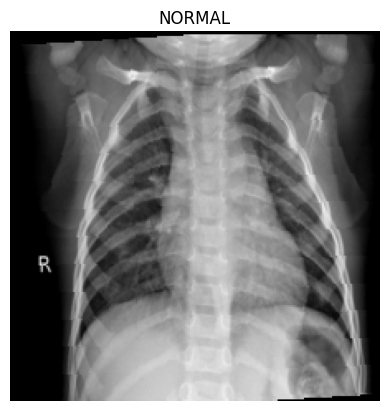

In [80]:
img, label = train_dataset[0]
img = img.permute(1, 2, 0).numpy()

mean = []
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

img = img * std + mean
img = img.clip(0, 1)

plt.imshow(img)
plt.title("NORMAL" if label == 0 else "PNEUMONIA")
plt.axis("off")
plt.show()

In [81]:
class_counts = Counter(train_dataset.labels)
print(class_counts)

sample_weights = [1.0 / class_counts[label] for label in train_dataset.labels]


Counter({1: 3100, 0: 1073})


In [82]:
sampler = WeightedRandomSampler(
    weights = sample_weights,
    num_samples = len(sample_weights),
    replacement = True
)

In [83]:
train_loader = DataLoader(train_dataset, batch_size = 32, sampler = sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size = 32, shuffle = False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = False, num_workers=2, pin_memory=True)

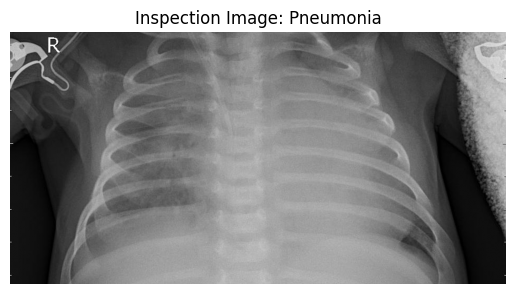

In [84]:
inspection_img_path = train_dataset.get_image(idx = 4000)
inspection_img = Image.open(inspection_img_path)
_, inspection_img_label = train_dataset.__getitem__(4000)

plt.title(f"Inspection Image: {"Normal" if inspection_img_label == 0 else "Pneumonia"}")

plt.imshow(inspection_img, cmap = "gray")
plt.axis("off")

plt.show()

## Trasfer Learning (Resnet 18) and Training the Model with Penumonia Dataset

In [85]:
model = models.resnet18(weights = models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 2) # 2 => Normal and Pneumonia
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode = 'max',
    factor = 0.1,
    patience = 2
)

In [68]:
epochs = 10

best_val_f1 = 0.0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(epochs):
  model.train()

  running_loss = 0.0
  train_correct = 0
  train_total = 0

  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

    running_loss += loss.item()

    _, preds = torch.max(outputs, 1)
    train_correct += (preds == labels).sum().item()
    train_total += labels.size(0)

  train_loss = running_loss / len(train_loader)
  train_acc = train_correct / train_total

  train_losses.append(train_loss)
  train_accuracies.append(train_acc)

  model.eval()
  val_labels = []
  val_preds = []
  val_loss = 0.0

  with torch.no_grad():
    for images, labels in val_loader:
      images = images.to(device)
      labels = labels.to(device)

      outputs = model(images)
      loss = criterion(outputs, labels)
      val_loss += loss.item()

      _, preds = torch.max(outputs, 1)

      val_labels.extend(labels.cpu().numpy())
      val_preds.extend(preds.cpu().numpy())

  val_loss = val_loss / len(val_loader)
  val_accuracy = accuracy_score(val_labels, val_preds)
  val_f1 = f1_score(val_labels, val_preds)

  val_losses.append(val_loss)
  val_accuracies.append(val_accuracy)

  print(f"Epoch: {epoch + 1}/{epochs}, loss: {train_loss}, val_loss:{val_loss}, accuracy: {train_acc}, val_accuracy: {val_accuracy}, val_f1: {val_f1}, lr: {optimizer.param_groups[0]['lr']}")

  scheduler.step(val_f1)

  if val_f1 > best_val_f1:
    best_val_f1 = val_f1
    torch.save(model.state_dict(), "/content/pneumonia_classifier.pth")
    print(f"New Best Model Saved (Val Accuracy: {val_accuracy:.4f})")



Epoch: 1/10, loss: 0.12718951625692596, val_loss:0.058537479151378975, accuracy: 0.9525521207764198, val_accuracy: 0.9789069990412272, val_f1: 0.9857512953367875, lr: 0.001
New Best Model Saved (Val Accuracy: 0.9789)
Epoch: 2/10, loss: 0.062289093565977824, val_loss:0.07633047835957824, accuracy: 0.9786724179247543, val_accuracy: 0.975071907957814, val_f1: 0.9829842931937173, lr: 0.001
Epoch: 3/10, loss: 0.057315444021009423, val_loss:0.33103878049455077, accuracy: 0.9772346034028278, val_accuracy: 0.9069990412272292, val_f1: 0.9333333333333333, lr: 0.001
Epoch: 4/10, loss: 0.058621784017193805, val_loss:0.09206559846643358, accuracy: 0.9774742391564821, val_accuracy: 0.975071907957814, val_f1: 0.9830065359477124, lr: 0.001
Epoch: 5/10, loss: 0.02124206287113644, val_loss:0.05205778502435847, accuracy: 0.9935298346513299, val_accuracy: 0.987535953978907, val_f1: 0.9915748541801686, lr: 0.0001
New Best Model Saved (Val Accuracy: 0.9875)
Epoch: 6/10, loss: 0.014018426988965242, val_loss:

## Model Evaluation

In [ ]:
plt.title("Losses")

plt.plot(train_losses, label = "Train Loss")
plt.plot(val_losses, label = "Validation Loss")
plt.legend()

plt.show()

In [72]:
model.load_state_dict(
    torch.load("/content/pneumonia_classifier.pth")
)

model.eval()

test_labels = []
test_preds = []

with torch.no_grad():
  for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    test_labels.extend(labels.cpu().numpy())
    test_preds.extend(preds.cpu().numpy())

test_accuracy = accuracy_score(test_labels, test_preds)
print(f"Test Accuracy: {test_accuracy}")

Test Accuracy: 0.8381410256410257


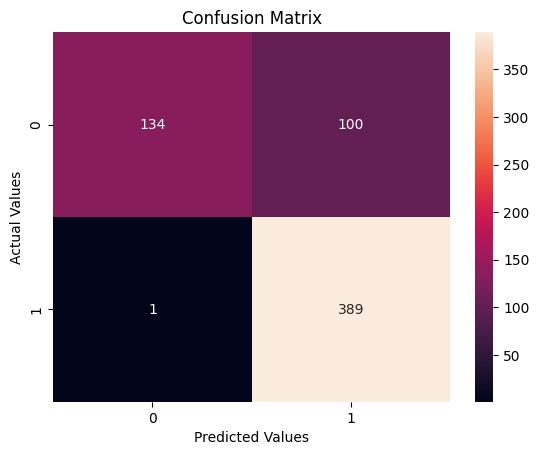

              precision    recall  f1-score   support

           0       0.99      0.57      0.73       234
           1       0.80      1.00      0.89       390

    accuracy                           0.84       624
   macro avg       0.89      0.79      0.81       624
weighted avg       0.87      0.84      0.83       624



In [70]:
cm = confusion_matrix(test_labels, test_preds)

plt.title("Confusion Matrix")

sns.heatmap(cm, annot = True, fmt='d')
plt.ylabel("Actual Values")
plt.xlabel("Predicted Values")

plt.show()

print(classification_report(test_labels, test_preds))